In [1]:
# required imports

!pip install openpyxl
import openpyxl

import xlrd
import random
import pandas as pd
import seaborn as sns
import geopandas as gpd
import matplotlib.pyplot as plt

sns.set_style('whitegrid')


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
# Read the first sheet from the Excel File

file_name = 'Yearwise.xlsx'
# Use openpyxl to open .xlsx files
wb = openpyxl.load_workbook(file_name)
# Access the desired sheet by name or index (e.g., 0 for the first sheet)
sheet = wb.active # or wb['Sheet1'] if the sheet name is 'Sheet1'


In [3]:
# Some pre-processing to prepare the DataFrame outof the excel file

prefix = 'Cases Reported during the Year (CR) Under Crime against Women in '
suffix = 'During 2001-2015'
state_name = None
key = None
info_list = []
info = dict()

# Get the maximum number of rows and columns
max_row = sheet.max_row
max_column = sheet.max_column


for i in range(1, max_row + 1): # Iterate through rows starting from index 1
    numbers = list()
    for j in range(1, max_column + 1): # Iterate through columns starting from index 1
        value = sheet.cell(row=i, column=j).value # Get cell value using openpyxl syntax
        if type(value) is str and not value.split():
            continue
        if value == 'SL':
            break
        if j == 1 and type(value) is str and 'Cases Reported during the Year' in value:
            state_name = value.replace(prefix, '').replace(suffix, '')
            info['state_name'] = state_name
            break
        if j == 2 and type(value) is str and value.split(): # Changed to column 2 for key
            key = value
            info[key] = None
        if type(value) is float or type(value) is int: # Include int type
            numbers.append(value)
    if numbers:
        info[key] = numbers[1:]
        n_keys = len(list(info.keys()))
        if n_keys == 16:
            info_list.append(info)
            info = dict()

keys = list(info_list[0].keys())
columns = keys.copy()
columns.insert(1,'Year')

final_list = list()

for il in info_list:
    year = 2001
    for i in range(15):
        temp_list = list()
        for k in keys[1:]:
            temp_list.append(il.get(k)[i])
        temp_list.insert(0, il.get('state_name').strip())
        temp_list.insert(1, year)
        year += 1
        final_list.append(temp_list)

In [4]:
# preview the prepared DataFrame

df = pd.DataFrame(final_list, columns=columns)
df.head()

,state_name,Year,Rape,Attempt to commit Rape,Kidnapping & Abduction of Women,Dowry Deaths,Assault on Women with intent to outrage her Modesty,Insult to the Modesty of Women,Cruelty by Husband or his Relatives,Importation of Girls from Foreign Country,Abetment of Suicides of Women,"Dowry Prohibition Act, 1961","Indecent Representation of Women (Prohibition) Act, 1986",Commission of Sati Prevention Act 1987,"Protection of Women from Domestic Violence Act, 2005",Immoral Traffic (Prevention) Act,Total Crimes against Women
0,Andhra Pradesh,2001,871.0,0.0,765.0,420.0,3544.0,2271.0,5791.0,7.0,0.0,551.0,925.0,0.0,0.0,1332.0,16477.0
1,Andhra Pradesh,2002,1002.0,0.0,854.0,449.0,3799.0,2024.0,7018.0,0.0,0.0,460.0,2403.0,0.0,0.0,871.0,18880.0
2,Andhra Pradesh,2003,946.0,0.0,931.0,466.0,4128.0,2286.0,8167.0,5.0,0.0,195.0,909.0,0.0,0.0,349.0,18382.0
3,Andhra Pradesh,2004,1016.0,0.0,1030.0,512.0,3817.0,2310.0,8388.0,2.0,0.0,339.0,1102.0,0.0,0.0,405.0,18921.0
4,Andhra Pradesh,2005,935.0,0.0,995.0,443.0,3595.0,2508.0,8696.0,3.0,0.0,306.0,2657.0,0.0,0.0,681.0,20819.0


In [5]:
# Keeping only the required columns

state_wise_total_crimes = df[['state_name', 'Total Crimes against Women', 'Year']]
data_for_map = state_wise_total_crimes[state_wise_total_crimes['Year']==2015]
data_for_map.head()

,state_name,Total Crimes against Women,Year
14,Andhra Pradesh,15931.0,2015
29,Arunachal Pradesh,384.0,2015
44,Assam,23258.0,2015
59,Bihar,13891.0,2015
74,Chhattisgarh,5720.0,2015


In [6]:
import shapefile
import geopandas as gpd

# Read the shapefile using pure-Python (bypasses pyogrio/fiona errors)
with shapefile.Reader("Igismap/Indian_States.shp") as sf:
    map_df = gpd.GeoDataFrame.from_features(sf.__geo_interface__, crs="EPSG:4326")

# Rename the state column to match what the rest of the notebook expects
map_df = map_df.rename(columns={'NAME_1': 'st_nm', 'State_Name': 'st_nm'})

map_df.head()

,geometry,st_nm
0,"MULTIPOLYGON (((93.71976 7.20707, 93.71909 7.2...",Andaman & Nicobar Island
1,"POLYGON ((96.16261 29.38078, 96.1686 29.37432,...",Arunanchal Pradesh
2,"MULTIPOLYGON (((89.74323 26.30362, 89.7429 26....",Assam
3,"MULTIPOLYGON (((84.5072 24.26323, 84.50355 24....",Bihar
4,"POLYGON ((76.84147 30.75996, 76.83599 30.73623...",Chandigarh


In [7]:
# Correct spellings of states from out dataframe to match those of GeoDataframe
# I found these 4 names manually

data_for_map['state_name'].iloc[29]  = 'Andaman & Nicobar Island'
data_for_map['state_name'].iloc[1] = 'Arunanchal Pradesh'
data_for_map['state_name'].iloc[31] = 'Dadara & Nagar Havelli'
data_for_map['state_name'].iloc[33] = 'NCT of Delhi'

C:\Users\Parv Desai\AppData\Local\Temp\ipykernel_6568\3091852216.py:4: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

Try using '.loc[row_indexer, col_indexer] = value' instead, to perform the assignment in a single step.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html#chained-assignment
  data_for_map['state_name'].iloc[29]  = 'Andaman & Nicobar Island'
C:\Users\Parv Desai\AppData\Local\Temp\ipykernel_6568\3091852216.py:5: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are

<Axes: >

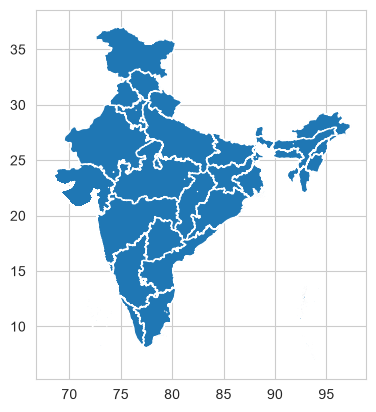

In [8]:
# Plot the default map

map_df.plot()

In [9]:
# Join both the DataFrames by state names

merged = map_df.set_index('st_nm').join(data_for_map.set_index('state_name'))
merged.head()

,geometry,Total Crimes against Women,Year
st_nm,,,
Andaman & Nicobar Island,"MULTIPOLYGON (((93.71976 7.20707, 93.71909 7.2...",NaN,NaN
Arunanchal Pradesh,"POLYGON ((96.16261 29.38078, 96.1686 29.37432,...",NaN,NaN
Assam,"MULTIPOLYGON (((89.74323 26.30362, 89.7429 26....",23258.0,2015.0
Bihar,"MULTIPOLYGON (((84.5072 24.26323, 84.50355 24....",13891.0,2015.0
Chandigarh,"POLYGON ((76.84147 30.75996, 76.83599 30.73623...",463.0,2015.0


In [10]:
# NA check

merged.isna().sum()

geometry                      0
Total Crimes against Women    4
Year                          4
dtype: int64

In [11]:
# Summary to get the max and min value

merged.describe()

,Total Crimes against Women,Year
count,32.000000,32.0
mean,9679.531250,2015.0
std,11046.047073,0.0
min,9.000000,2015.0
25%,357.250000,2015.0
50%,5783.500000,2015.0
75%,15334.000000,2015.0
max,35527.000000,2015.0


findfont: Failed to find font weight 3, now using 400.


<Axes: title={'center': 'State Wise Crime against women in India in 2015'}>

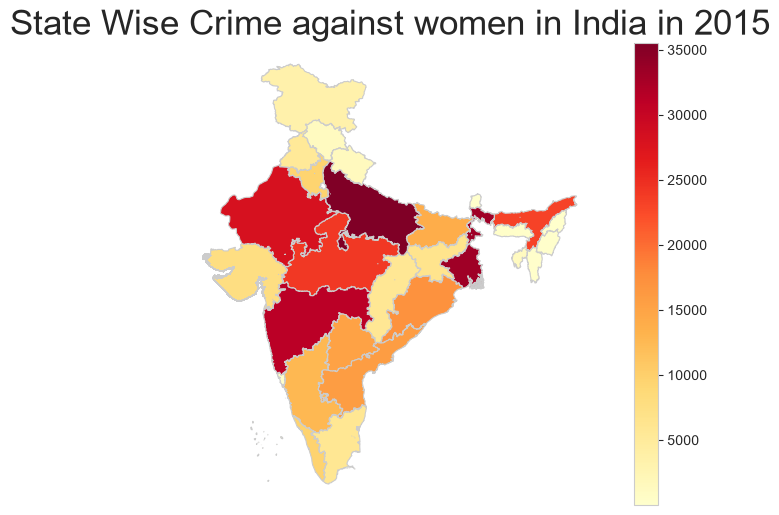

In [12]:
# create figure and axes for Matplotlib and set the title
fig, ax = plt.subplots(1, figsize=(10, 6))
ax.axis('off')
ax.set_title('State Wise Crime against women in India in 2015', fontdict={'fontsize': '25', 'fontweight' : '3'})

# plot the figure
merged.plot(column='Total Crimes against Women', cmap='YlOrRd', linewidth=0.8, ax=ax, edgecolor='0.8', legend=True)

In [13]:
# We save the output as a PNG image

fig.savefig("State_wise.png", dpi=100)

In [14]:
import shapefile
import geopandas as gpd

# Read the district-wise shapefile using pure-Python (bypasses pyogrio/fiona errors)
with shapefile.Reader("gadm36_IND_shp/gadm36_IND_2.shp") as sf:
    map_df = gpd.GeoDataFrame.from_features(sf.__geo_interface__, crs="EPSG:4326")

map_df.head()

,geometry,GID_0,NAME_0,GID_1,NAME_1,NL_NAME_1,GID_2,NAME_2,VARNAME_2,NL_NAME_2,TYPE_2,ENGTYPE_2,CC_2,HASC_2
0,"MULTIPOLYGON (((93.78773 6.85264, 93.78849 6.8...",IND,India,IND.1_1,Andaman and Nicobar,,IND.1.1_1,Nicobar Islands,,,District,District,,IN.AN.NI
1,"MULTIPOLYGON (((92.93898 12.22386, 92.93916 12...",IND,India,IND.1_1,Andaman and Nicobar,,IND.1.2_1,North and Middle Andaman,,,District,District,,IN.AN.NM
2,"MULTIPOLYGON (((92.47972 10.52056, 92.47945 10...",IND,India,IND.1_1,Andaman and Nicobar,,IND.1.3_1,South Andaman,,,District,District,,IN.AN.SA
3,"POLYGON ((77.7142 13.76079, 77.71314 13.75074,...",IND,India,IND.2_1,Andhra Pradesh,,IND.2.1_1,Anantapur,"Anantpur, Ananthapur",,District,District,,IN.AD.AN
4,"POLYGON ((78.46293 12.63537, 78.4619 12.63228,...",IND,India,IND.2_1,Andhra Pradesh,,IND.2.2_1,Chittoor,Chitoor|Chittor,,District,District,,IN.AD.CH


<Axes: >

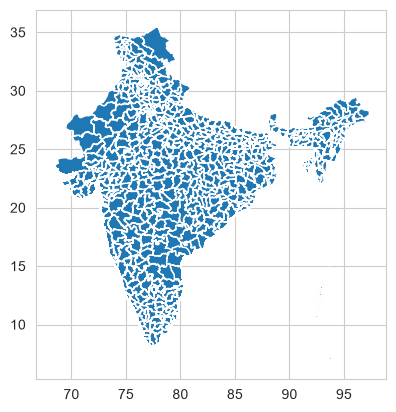

In [15]:
# keep required columns and plot default map

map_df = map_df[['NAME_2', 'geometry']]
map_df.plot()

In [16]:
# read the district wise excel file and preview it

district_wise = pd.read_excel('district_wise.xls')
district_wise.head()

WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero


,State/ UT,Sl. No.,District/ Area,Year,Rape,Attempt to commit Rape,Kidnapping & Abduction_Total,Dowry Deaths,Assault on Women with intent to outrage her Modesty_Total,Insult to the Modesty of Women_Total,Cruelty by Husband or his Relatives,Importation of Girls from Foreign Country,Abetment of Suicides of Women,"Dowry Prohibition Act, 1961","Indecent Representation of Women (P) Act, 1986",Protection of Children from Sexual Offences Act,"Protection of Women from Domestic Violence Act, 2005",Immoral Traffic Prevention Act,Total Crimes against Women
0,Andhra Pradesh,1,Anantapur,2015.0,32.0,15.0,57.0,12.0,325.0,8.0,276.0,0.0,62.0,157.0,0.0,0.0,0.0,8.0,952.0
1,Andhra Pradesh,2,Chittoor,2015.0,31.0,0.0,20.0,10.0,94.0,1.0,202.0,0.0,0.0,0.0,0.0,0.0,0.0,8.0,366.0
2,Andhra Pradesh,3,Cuddapah,2015.0,34.0,7.0,17.0,6.0,211.0,82.0,317.0,0.0,3.0,11.0,0.0,0.0,0.0,2.0,690.0
3,Andhra Pradesh,4,East Godavari,2015.0,104.0,19.0,25.0,13.0,574.0,150.0,522.0,0.0,0.0,3.0,9.0,0.0,0.0,19.0,1438.0
4,Andhra Pradesh,5,Guntakal Railway,2015.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [17]:
# keeping only the required columns

district_wise = district_wise[['District/ Area', 'Total Crimes against Women']]

In [18]:
# Join both the DataFrames by district names

merged = map_df.set_index('NAME_2').join(district_wise.set_index('District/ Area'))
merged.head()

,geometry,Total Crimes against Women
NAME_2,,
Nicobar Islands,"MULTIPOLYGON (((93.78773 6.85264, 93.78849 6.8...",NaN
North and Middle Andaman,"MULTIPOLYGON (((92.93898 12.22386, 92.93916 12...",NaN
South Andaman,"MULTIPOLYGON (((92.47972 10.52056, 92.47945 10...",79.0
Anantapur,"POLYGON ((77.7142 13.76079, 77.71314 13.75074,...",952.0
Chittoor,"POLYGON ((78.46293 12.63537, 78.4619 12.63228,...",366.0


In [19]:
# NA Check

merged.isna().sum()

geometry                        0
Total Crimes against Women    185
dtype: int64

##### Seems like there are around 185 district names that are either mispelled or missing
##### I am not going to do correct these manually instead we will impute them with the mean (even though that will make our data incorrect but the propose of this notebook is to show you how to use GeoPandas to plot District wise stats on the Map of India)

In [20]:
# Impute missing values by mean

merged['Total Crimes against Women'].fillna(merged['Total Crimes against Women'].mean(), inplace=True)
merged.isna().sum()

C:\Users\Parv Desai\AppData\Local\Temp\ipykernel_6568\994641608.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  merged['Total Crimes against Women'].fillna(merged['Total Crimes against Women'].mean(), inplace=True)


geometry                        0
Total Crimes against Women    185
dtype: int64

In [21]:
# summary

merged.describe()

,Total Crimes against Women
count,491.000000
mean,422.541752
std,448.159483
min,0.000000
25%,139.500000
50%,295.000000
75%,548.500000
max,4073.000000


<Axes: title={'center': 'District Wise Crime against women in India in 2015'}>

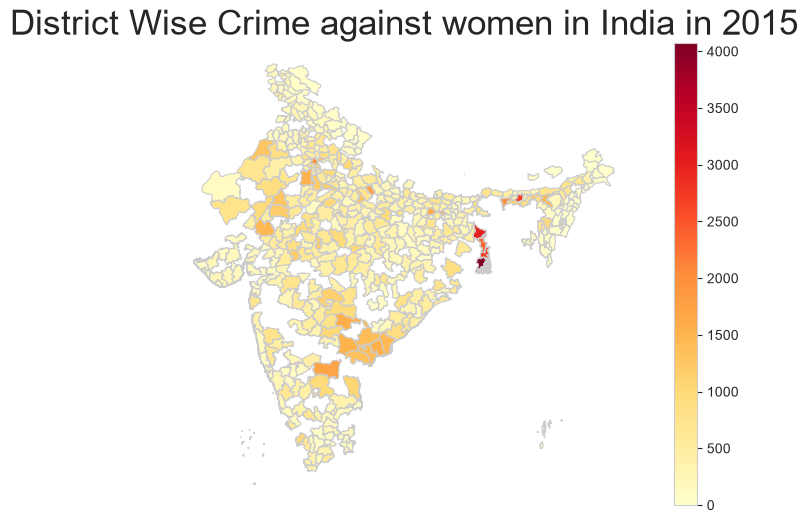

In [22]:
# create figure and axes for Matplotlib and set the title
fig, ax = plt.subplots(1, figsize=(10, 6))
ax.axis('off')
ax.set_title('District Wise Crime against women in India in 2015', fontdict={'fontsize': '25', 'fontweight' : '3'})

# plot the figure
merged.plot(column='Total Crimes against Women', cmap='YlOrRd', linewidth=0.8, ax=ax, edgecolor='0.8', legend=True)

In [23]:
# We save the output as a PNG image

fig.savefig("District_wise.png", dpi=100)

In [24]:
import shapefile
import geopandas as gpd

# Read the district shapefile using pure-Python (bypasses the driver error)
with shapefile.Reader("gadm36_IND_shp/gadm36_IND_2.shp") as sf:
    map_df = gpd.GeoDataFrame.from_features(sf.__geo_interface__, crs="EPSG:4326")

map_df.head()

,geometry,GID_0,NAME_0,GID_1,NAME_1,NL_NAME_1,GID_2,NAME_2,VARNAME_2,NL_NAME_2,TYPE_2,ENGTYPE_2,CC_2,HASC_2
0,"MULTIPOLYGON (((93.78773 6.85264, 93.78849 6.8...",IND,India,IND.1_1,Andaman and Nicobar,,IND.1.1_1,Nicobar Islands,,,District,District,,IN.AN.NI
1,"MULTIPOLYGON (((92.93898 12.22386, 92.93916 12...",IND,India,IND.1_1,Andaman and Nicobar,,IND.1.2_1,North and Middle Andaman,,,District,District,,IN.AN.NM
2,"MULTIPOLYGON (((92.47972 10.52056, 92.47945 10...",IND,India,IND.1_1,Andaman and Nicobar,,IND.1.3_1,South Andaman,,,District,District,,IN.AN.SA
3,"POLYGON ((77.7142 13.76079, 77.71314 13.75074,...",IND,India,IND.2_1,Andhra Pradesh,,IND.2.1_1,Anantapur,"Anantpur, Ananthapur",,District,District,,IN.AD.AN
4,"POLYGON ((78.46293 12.63537, 78.4619 12.63228,...",IND,India,IND.2_1,Andhra Pradesh,,IND.2.2_1,Chittoor,Chitoor|Chittor,,District,District,,IN.AD.CH


<Axes: >

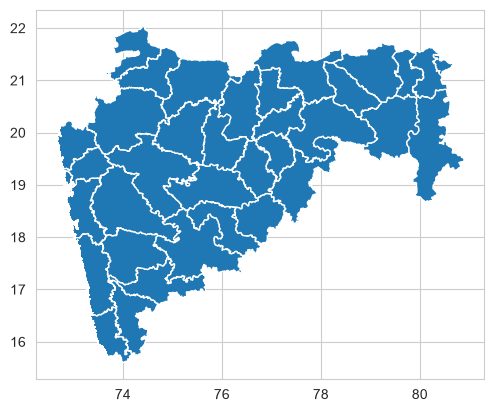

In [25]:
map_df = map_df[['NAME_1', 'NAME_2', 'geometry']]
map_df = map_df[map_df['NAME_1']=='Maharashtra']
map_df.plot()

In [26]:
district_wise = pd.read_excel('district_wise.xls')
district_wise.head()

WARNING *** OLE2 inconsistency: SSCS size is 0 but SSAT size is non-zero


,State/ UT,Sl. No.,District/ Area,Year,Rape,Attempt to commit Rape,Kidnapping & Abduction_Total,Dowry Deaths,Assault on Women with intent to outrage her Modesty_Total,Insult to the Modesty of Women_Total,Cruelty by Husband or his Relatives,Importation of Girls from Foreign Country,Abetment of Suicides of Women,"Dowry Prohibition Act, 1961","Indecent Representation of Women (P) Act, 1986",Protection of Children from Sexual Offences Act,"Protection of Women from Domestic Violence Act, 2005",Immoral Traffic Prevention Act,Total Crimes against Women
0,Andhra Pradesh,1,Anantapur,2015.0,32.0,15.0,57.0,12.0,325.0,8.0,276.0,0.0,62.0,157.0,0.0,0.0,0.0,8.0,952.0
1,Andhra Pradesh,2,Chittoor,2015.0,31.0,0.0,20.0,10.0,94.0,1.0,202.0,0.0,0.0,0.0,0.0,0.0,0.0,8.0,366.0
2,Andhra Pradesh,3,Cuddapah,2015.0,34.0,7.0,17.0,6.0,211.0,82.0,317.0,0.0,3.0,11.0,0.0,0.0,0.0,2.0,690.0
3,Andhra Pradesh,4,East Godavari,2015.0,104.0,19.0,25.0,13.0,574.0,150.0,522.0,0.0,0.0,3.0,9.0,0.0,0.0,19.0,1438.0
4,Andhra Pradesh,5,Guntakal Railway,2015.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [27]:
# keeping only the required columns

district_wise = district_wise[['State/ UT', 'District/ Area', 'Total Crimes against Women']]
district_wise = district_wise[district_wise['State/ UT']=='Maharashtra']
district_wise.head()

,State/ UT,District/ Area,Total Crimes against Women
417,Maharashtra,Ahmednagar,953.0
418,Maharashtra,Akola,489.0
419,Maharashtra,Amravati Commr.,501.0
420,Maharashtra,Amravati Rural,948.0
421,Maharashtra,Aurangabad Commr.,882.0


In [28]:
# Correct spellings of states from out dataframe to match those of GeoDataframe
# I corrected these names manually

district_wise['District/ Area'].iloc[0] = 'Ahmadnagar'


# 1449 is the sum of Amravati Commr and Amravati Rural from the district wise dataframe
district_wise = pd.concat([district_wise, pd.DataFrame([{'State/ UT': 'Maharashtra', 'District/ Area':'Amravati','Total Crimes against Women':1449.0}])], ignore_index=True)

# 1449 is the sum of Aurangabad Commr and Aurangabad Rural from the district wise Dataframe
# same is done for rest of the cities
district_wise = pd.concat([district_wise, pd.DataFrame([{'State/ UT': 'Maharashtra', 'District/ Area':'Aurangabad','Total Crimes against Women':1421.0}])], ignore_index=True)

district_wise['District/ Area'].iloc[6] = 'Bid'

district_wise['District/ Area'].iloc[8] = 'Buldana'

district_wise['District/ Area'].iloc[11]  = 'Garhchiroli'

district_wise['District/ Area'].iloc[12]  = 'Gondiya'

district_wise['District/ Area'].iloc[18] = 'Mumbai City'

district_wise['District/ Area'].iloc[19] = 'Mumbai Suburban'

district_wise = pd.concat([district_wise, pd.DataFrame([{'State/ UT': 'Maharashtra', 'District/ Area':'Nagpur','Total Crimes against Women':1754.0}])], ignore_index=True)

district_wise = pd.concat([district_wise, pd.DataFrame([{'State/ UT': 'Maharashtra', 'District/ Area':'Nashik','Total Crimes against Women':1416.0}])], ignore_index=True)

district_wise = pd.concat([district_wise, pd.DataFrame([{'State/ UT': 'Maharashtra', 'District/ Area':'Pune','Total Crimes against Women':1993.0}])], ignore_index=True)

district_wise['District/ Area'].iloc[34] = 'Raigarh'

district_wise = pd.concat([district_wise, pd.DataFrame([{'State/ UT': 'Maharashtra', 'District/ Area':'Thane','Total Crimes against Women':2289.0}])], ignore_index=True)

district_wise = pd.concat([district_wise, pd.DataFrame([{'State/ UT': 'Maharashtra', 'District/ Area':'Solapur','Total Crimes against Women':874.0}])], ignore_index=True)

C:\Users\Parv Desai\AppData\Local\Temp\ipykernel_6568\1191336371.py:4: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

Try using '.loc[row_indexer, col_indexer] = value' instead, to perform the assignment in a single step.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html#chained-assignment
  district_wise['District/ Area'].iloc[0] = 'Ahmadnagar'
C:\Users\Parv Desai\AppData\Local\Temp\ipykernel_6568\1191336371.py:14: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment.
Such chained assignment never works to update the original DataFrame or Series, because the intermediate object on which we are setting v

In [29]:
# Join both the DataFrames by district names

merged = map_df.set_index('NAME_2').join(district_wise.set_index('District/ Area'))
merged.head()

,NAME_1,geometry,State/ UT,Total Crimes against Women
NAME_2,,,,
Ahmadnagar,Maharashtra,"POLYGON ((74.83829 18.33893, 74.83713 18.3418,...",NaN,NaN
Akola,Maharashtra,"POLYGON ((76.82024 20.28149, 76.81767 20.28176...",Maharashtra,489.0
Amravati,Maharashtra,"POLYGON ((78.08906 21.18236, 78.09028 21.17835...",Maharashtra,1449.0
Aurangabad,Maharashtra,"POLYGON ((75.21554 19.5577, 75.20956 19.56258,...",Maharashtra,1421.0
Bhandara,Maharashtra,"MULTIPOLYGON (((80.43332 21.09715, 80.42831 21...",Maharashtra,225.0


In [30]:
# NA Check

merged.isna().sum()

NAME_1                        0
geometry                      0
State/ UT                     8
Total Crimes against Women    8
dtype: int64

In [31]:
# summary

merged.describe()

,Total Crimes against Women
count,28.000000
mean,764.250000
std,578.355563
min,91.000000
25%,405.750000
50%,580.500000
75%,934.250000
max,2289.000000


<Axes: title={'center': 'District Wise Crime against women in Maharastra in 2015'}>

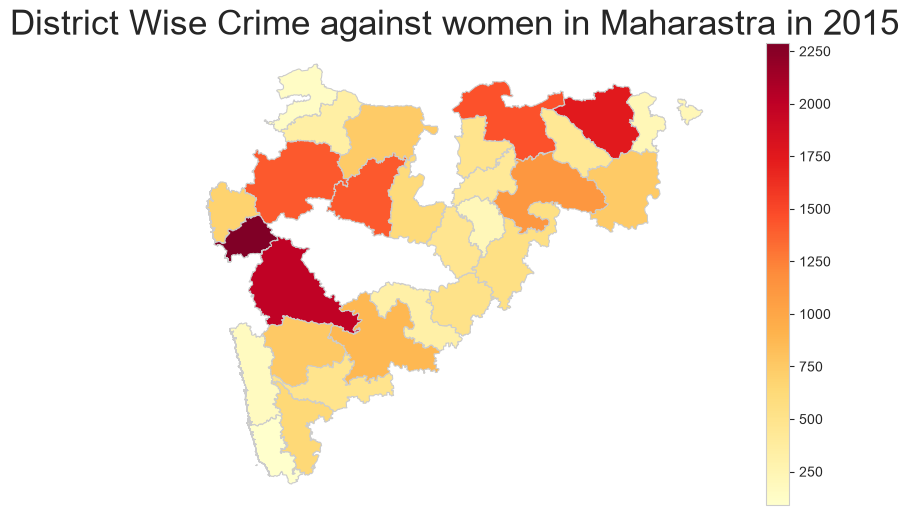

In [32]:
# create figure and axes for Matplotlib and set the title
fig, ax = plt.subplots(1, figsize=(10, 6))
ax.axis('off')
ax.set_title('District Wise Crime against women in Maharastra in 2015', fontdict={'fontsize': '25', 'fontweight' : '3'})

# plot the figure
merged.plot(column='Total Crimes against Women', cmap='YlOrRd', linewidth=0.8, ax=ax, edgecolor='0.8', legend=True)

In [33]:
# Saving the output as a PNG image

fig.savefig("Maharashtra.png", dpi=100)

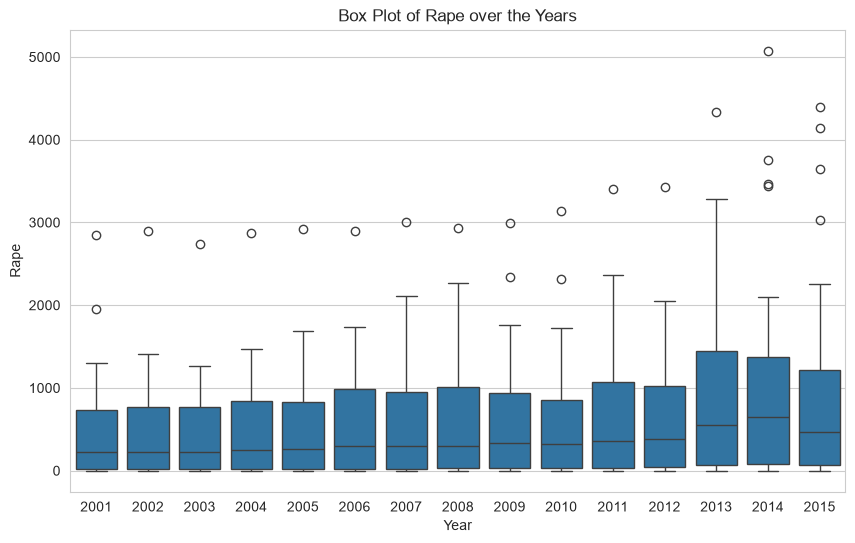

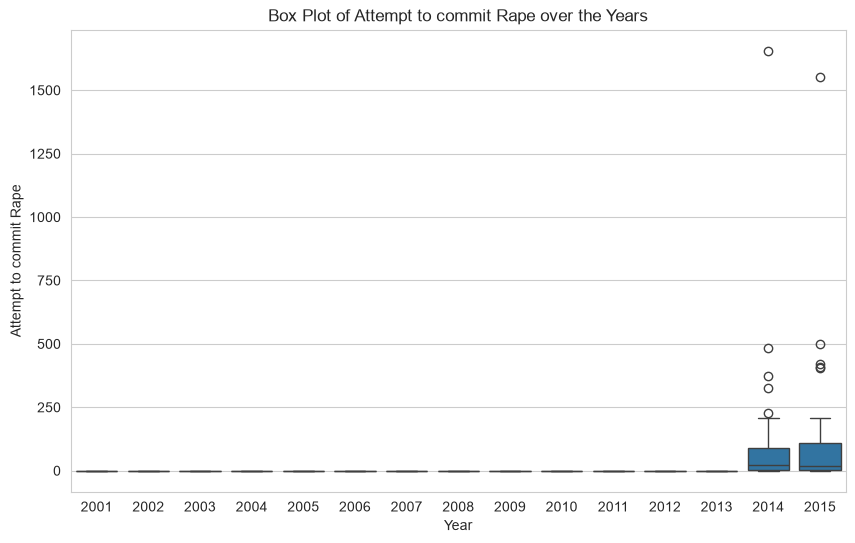

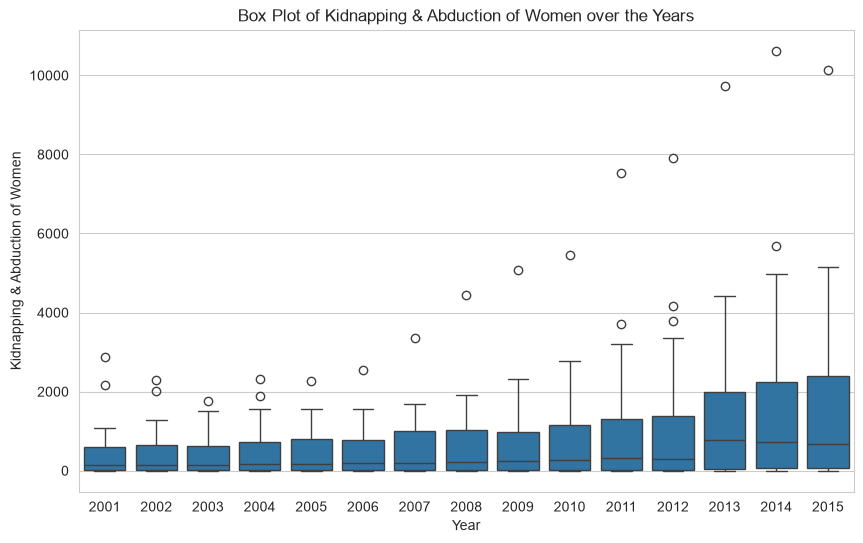

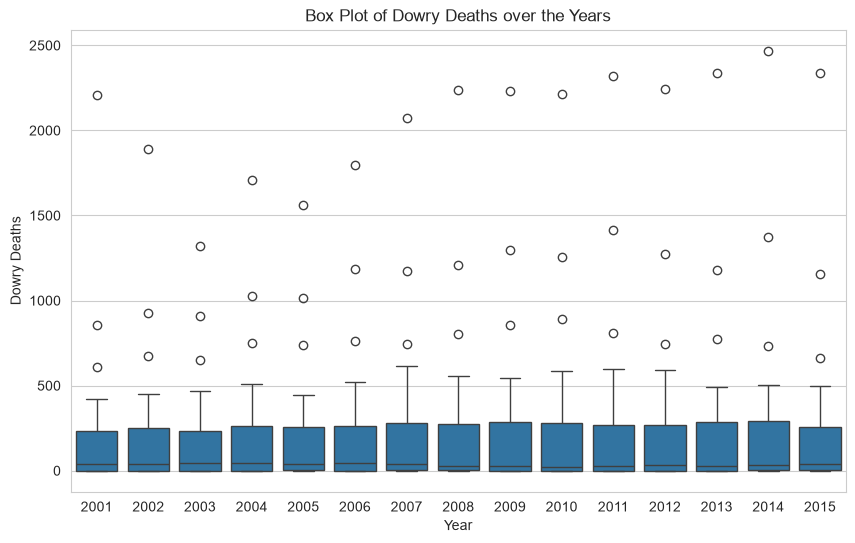

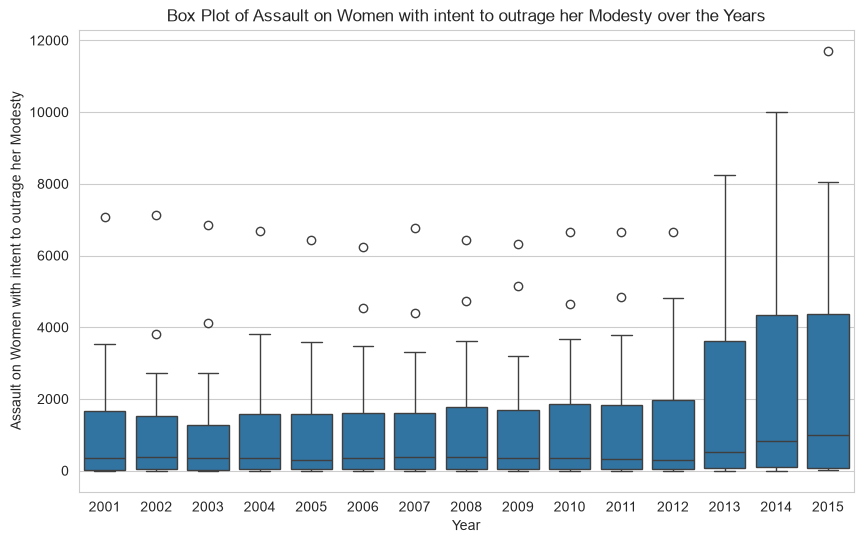

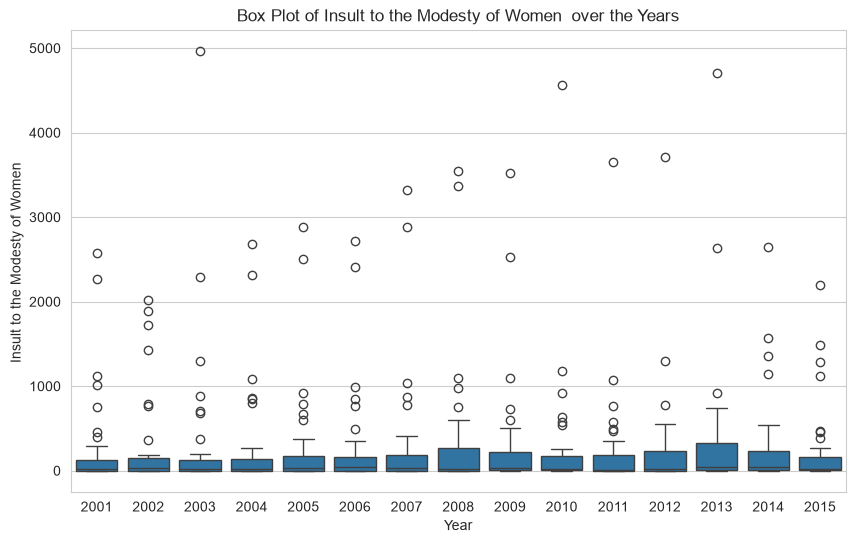

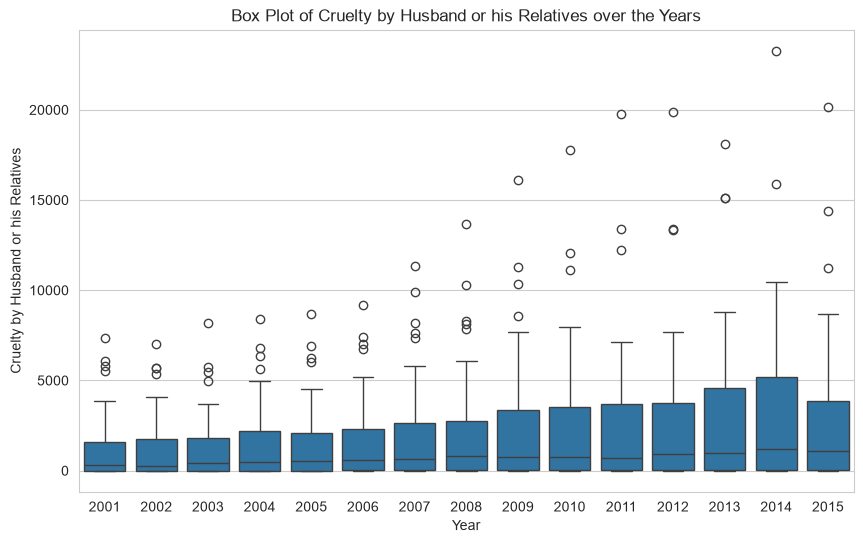

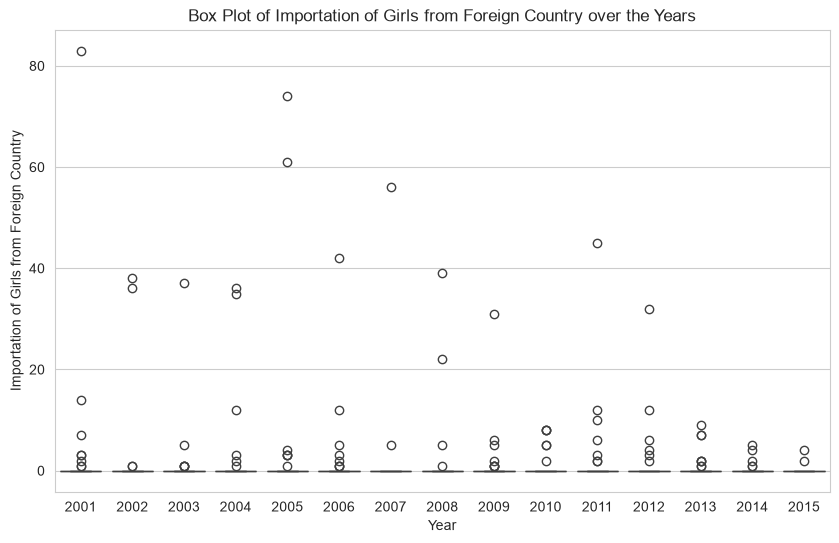

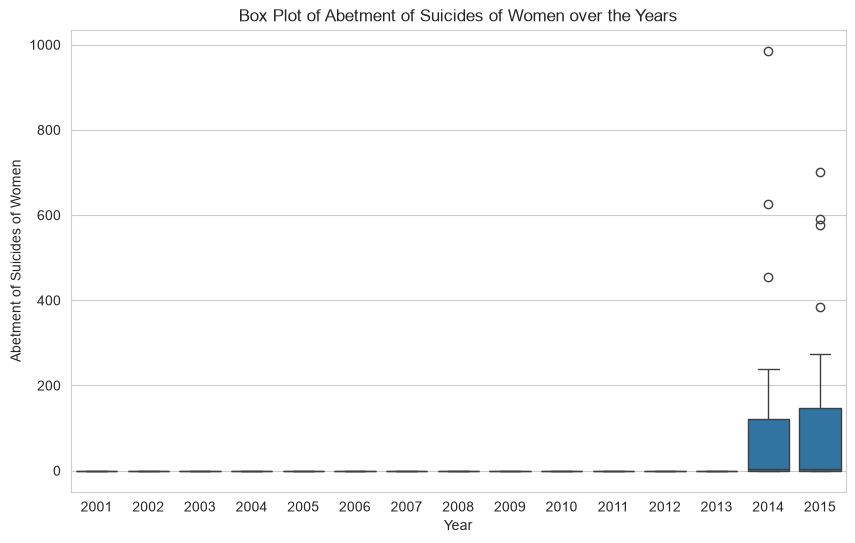

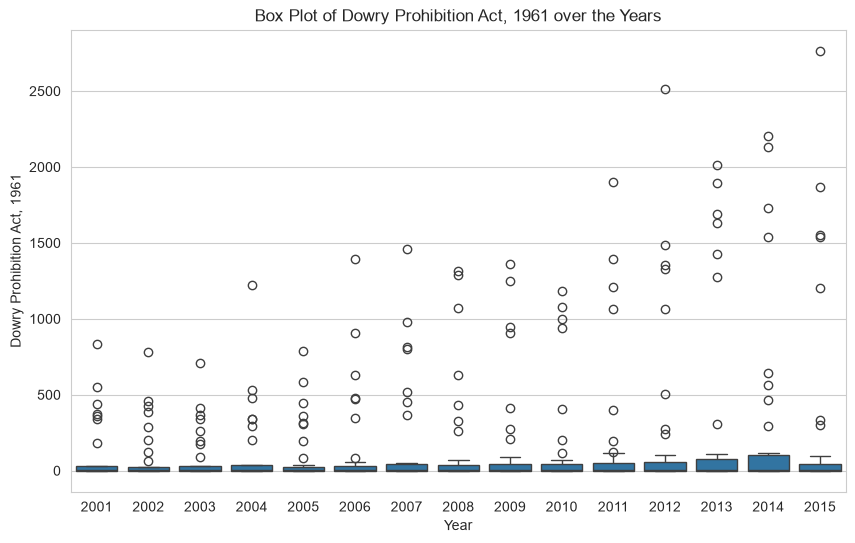

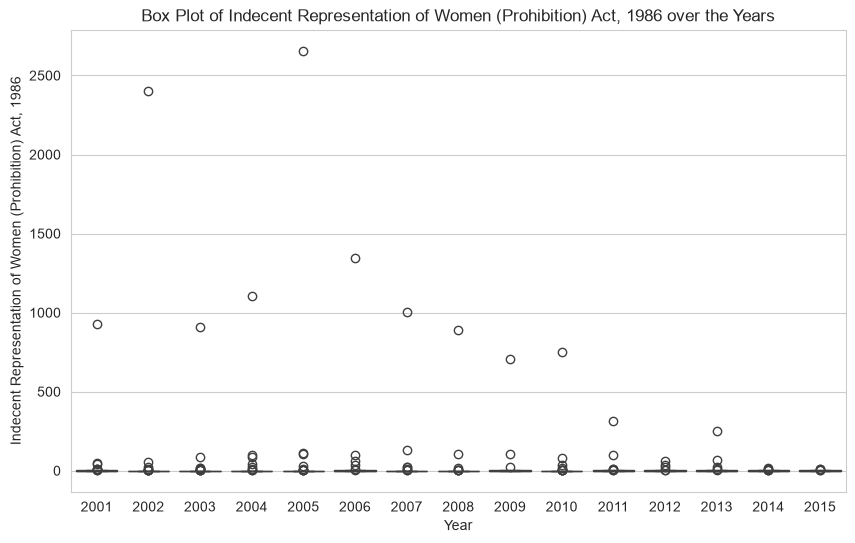

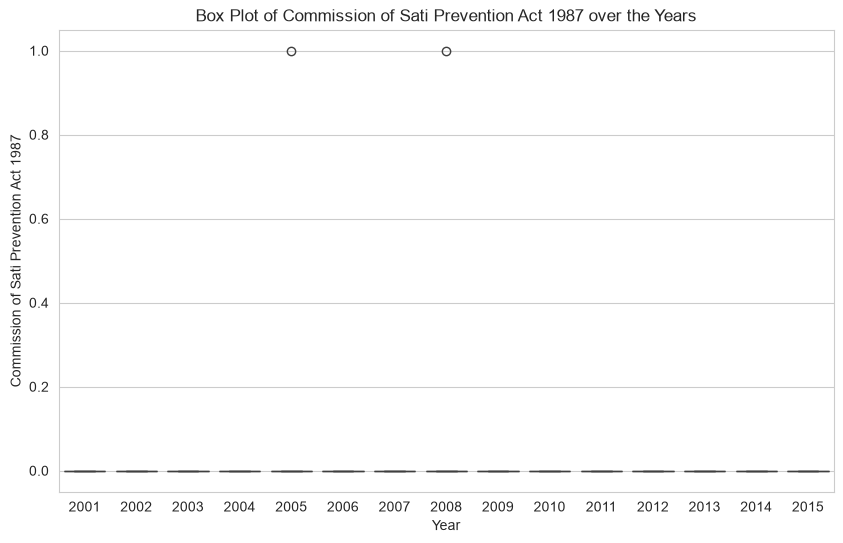

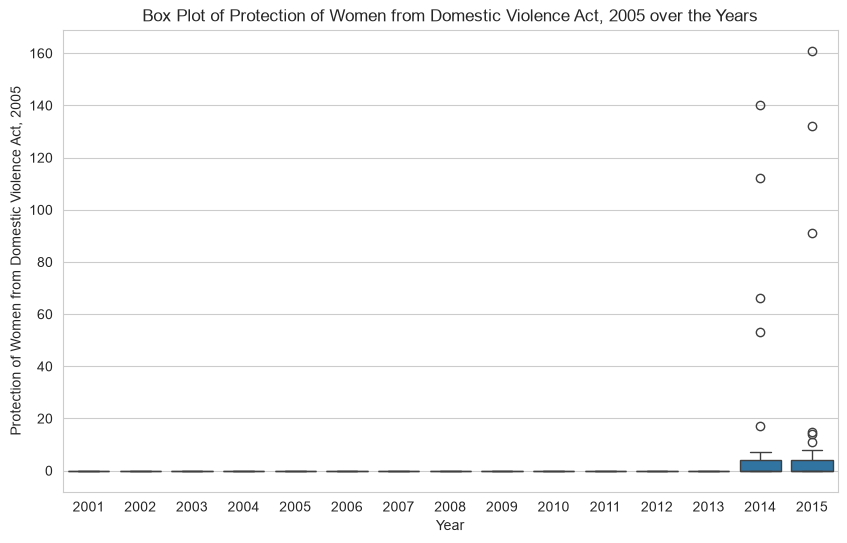

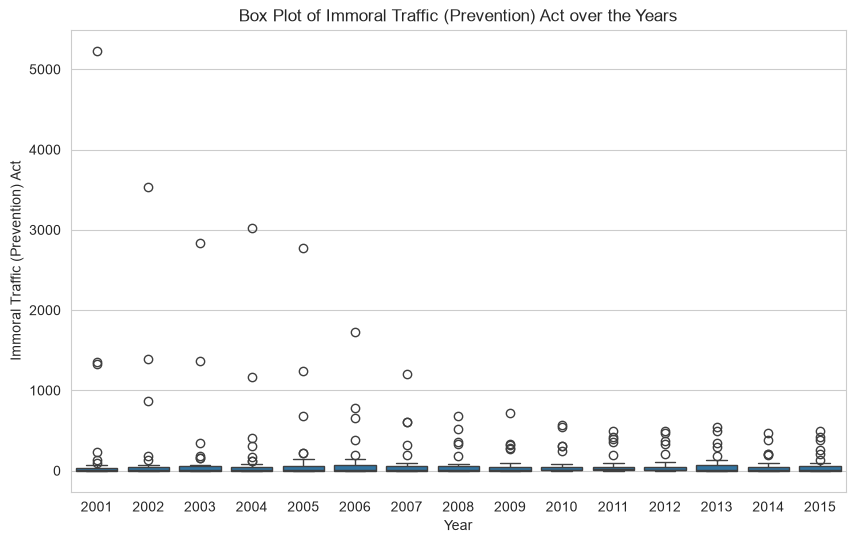

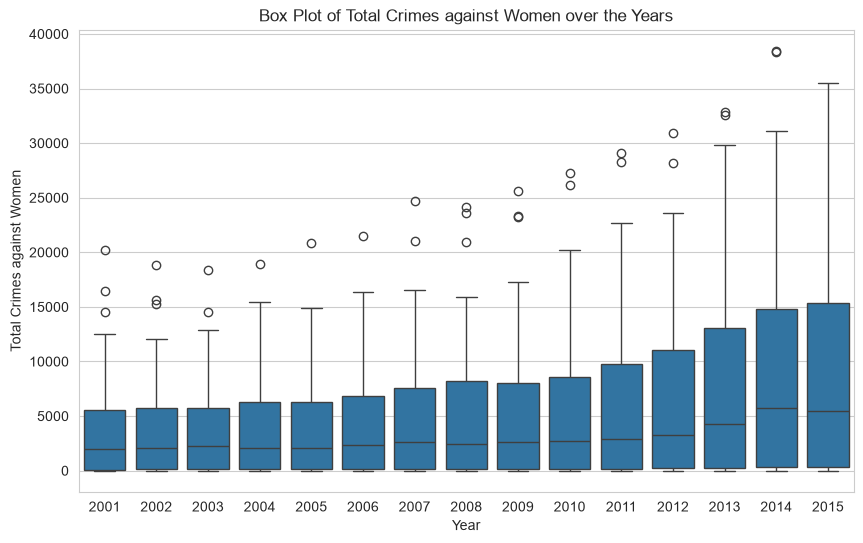

In [34]:
# prompt: generate the box plot for all the columns in the dataset Yearwise.xlsx with all columns

# Assuming 'df' is your DataFrame from the previous code

# Create the box plots
for col in df.columns:
  if col not in ['state_name', 'Year']:  # Skip non-numeric columns
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='Year', y=col, data=df)
    plt.title(f'Box Plot of {col} over the Years')
    plt.xlabel('Year')
    plt.ylabel(col)
    plt.show()


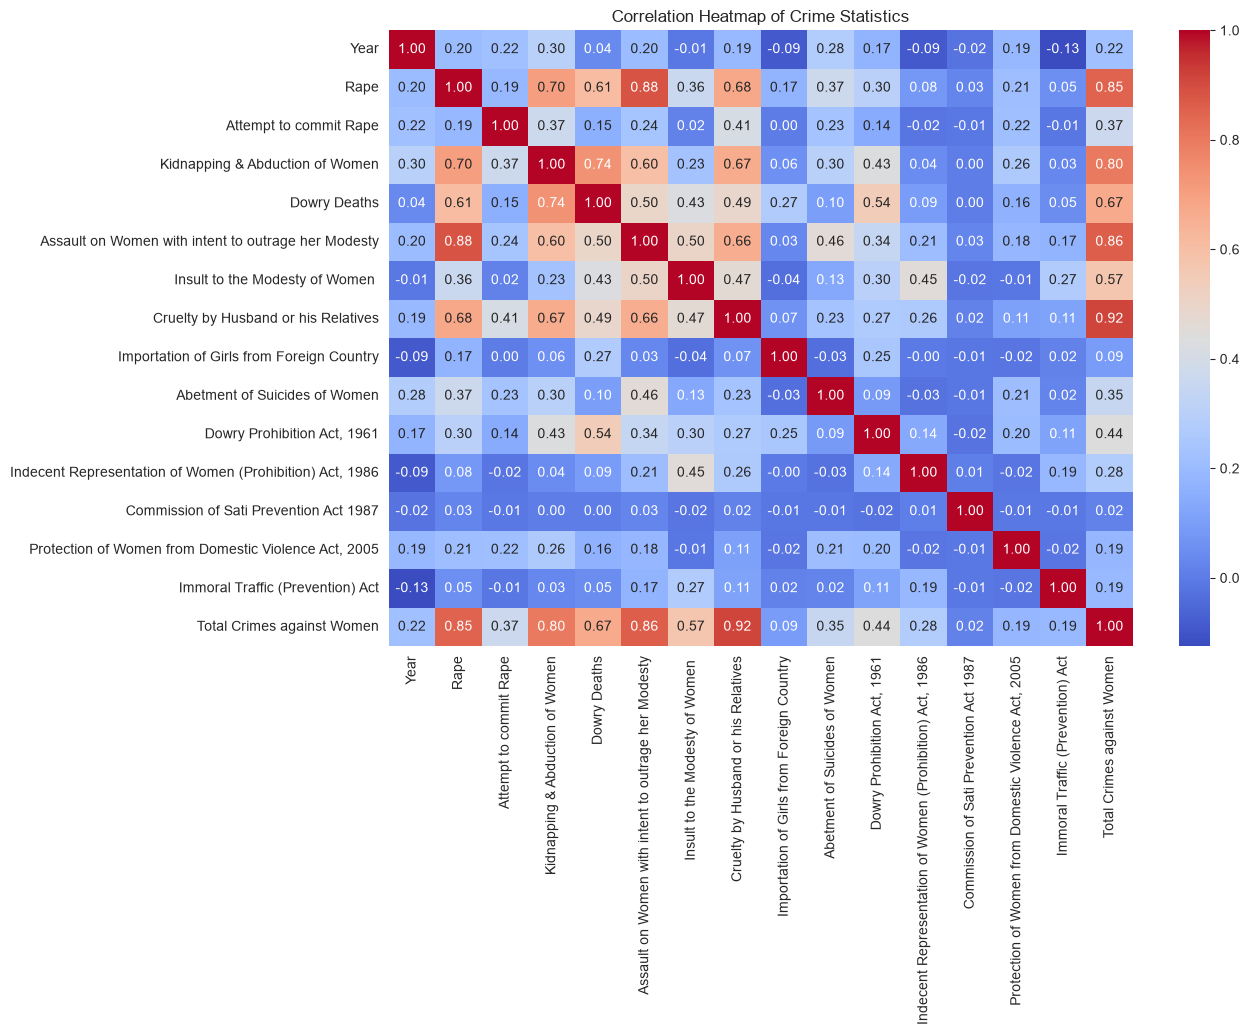

In [35]:
# prompt: also generate the heatmap for the same

# Assuming 'df' is your DataFrame from the previous code

# Create the heatmap
plt.figure(figsize=(12, 8))
# Select only numeric columns for correlation calculation
numeric_df = df.select_dtypes(include=['number'])
correlation_matrix = numeric_df.corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Crime Statistics')
plt.show()